<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/Correlation_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xee
import xee

In [2]:
import ee
import xarray as xr

In [3]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [4]:
col = ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE").filterDate('2010','2020').select('pr', 'tmmn', 'tmmx')


In [6]:
bangladesh = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Bangladesh'))


In [7]:
ds = xr.open_dataset(col, engine = 'ee', crs = 'EPSG:4326', scale = 0.05, geometry = bangladesh.geometry())

In [ ]:
ds

In [ ]:
pr_annual = ds.pr.resample(time = 'YE').sum('time')

pr_annual

In [11]:
import matplotlib.pyplot as plt

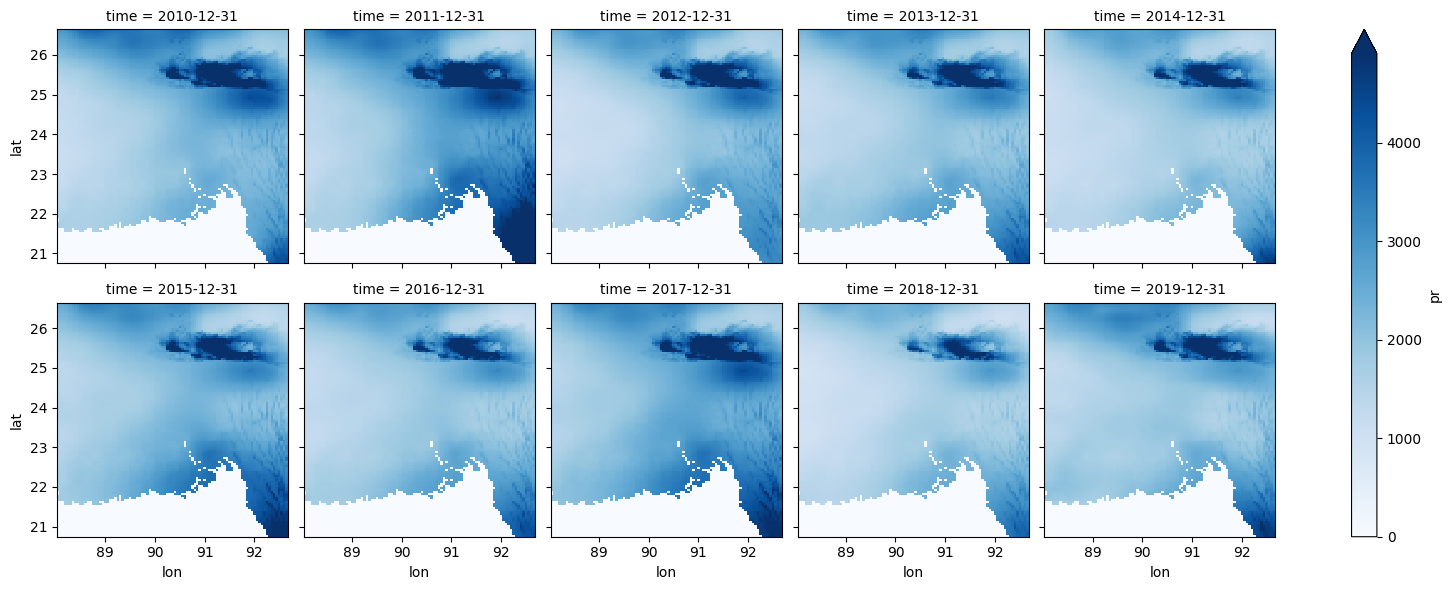

In [12]:
pr_annual.plot(x = 'lon', y = 'lat', cmap = 'Blues', col = 'time', col_wrap = 5, robust = True)


In [ ]:
temp = (((ds.tmmn + ds.tmmx)/2) * 0.1).round(2).rename('temp')

temp

In [ ]:
temp_annual = temp.resample(time = 'YE').mean('time')

temp_annual

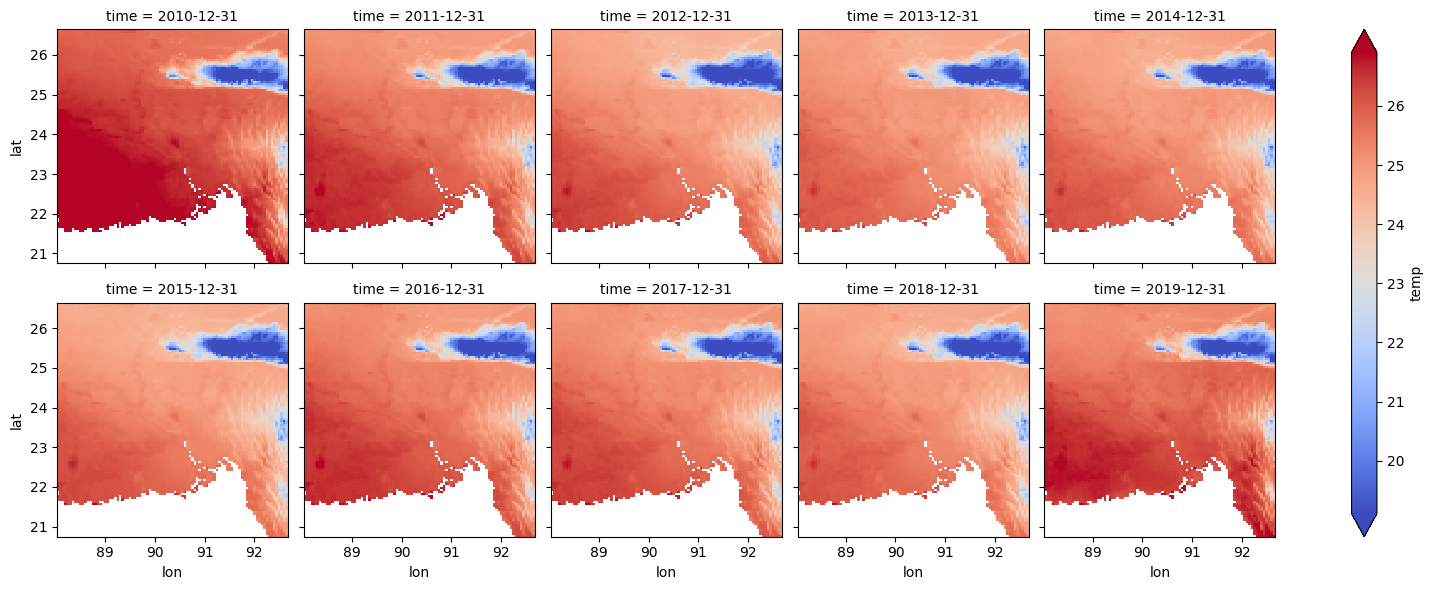

In [15]:
temp_annual.plot(x = 'lon', y = 'lat', cmap = 'coolwarm', robust = True, col = 'time', col_wrap = 5)


In [ ]:
cor_map = xr.corr(temp_annual, pr_annual, dim = 'time')

cor_map

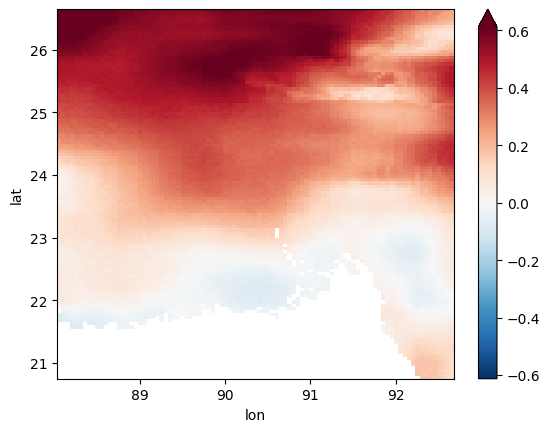

In [17]:
cor_map.plot(x = 'lon', y = 'lat', robust = True)